### Imports

In [ ]:
import os, sys

# Go to the repo root (adjust path if needed)
%cd /content/Data-Science-Project

# Make sure repo root is on sys.path
repo_root = os.getcwd()
if repo_root not in sys.path:
    sys.path.append(repo_root)

print("Using repo_root:", repo_root)

/content/Data-Science-Project
Using repo_root: /content/Data-Science-Project


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from data.crisismmd import (
    load_crisismmd_annotations,
    CrisisVisionDataset,
    make_train_transforms,
    make_eval_transforms,
)
from models.vision_branch import build_resnet_classifier, VisionDatasetWrapper
from training.utils import train_one_epoch, evaluate, seed_everything

### Load CrisisMMD dataset

In [3]:
seed_everything(42)

# Root directory where you extracted CrisisMMD_v2.0
root = "../CrisisMMD_v2.0"  # adjust if needed

# Load and merge all annotation .tsv files
combined = load_crisismmd_annotations(root)

# Keep the columns we care about
dataset_df = combined[["tweet_id", "image_id", "text_info", "image_info", "tweet_text", "image_path"]]

# Split into train / validation
train_df, val_df = train_test_split(dataset_df, test_size=0.2, random_state=42)

# Transforms
train_tf = make_train_transforms()
val_tf   = make_eval_transforms()

# Base datasets: each returns (image_tensor, label)
base_train_ds = CrisisVisionDataset(train_df, root_dir=root, transform=train_tf)
base_val_ds   = CrisisVisionDataset(val_df,   root_dir=root, transform=val_tf)

# Wrapped datasets: each returns ((image_tensor,), label)
train_ds = VisionDatasetWrapper(base_train_ds)
val_ds   = VisionDatasetWrapper(base_val_ds)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)

# Quick sanity check
images_batch, labels_batch = next(iter(train_loader))
print("Batch images shape:", images_batch[0].shape)  # images_batch is a tuple with one tensor
print("Batch labels shape:", labels_batch.shape)

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])


### Build model, criterion and optimizer

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = build_resnet_classifier(num_classes=2, pretrained=True).to(device)

# Freeze everything, then unfreeze layer4 and fc (as in your original notebook)
for p in model.parameters():
    p.requires_grad = False
for p in model.layer4.parameters():
    p.requires_grad = True
for p in model.fc.parameters():
    p.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    [
        {"params": model.layer4.parameters(), "lr": 1e-4},
        {"params": model.fc.parameters(),     "lr": 1e-3},
    ]
)

EPOCHS = 10

train_loss_hist = []
train_acc_hist  = []
val_loss_hist   = []
val_acc_hist    = []


Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 136MB/s]


### Train the model

In [5]:
best_val_loss = float("inf")
best_state_dict = None

print("Starting ResNet training...")

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # train_one_epoch / evaluate from training/utils.py
    train_loss, train_acc = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    val_loss, val_acc, _, _, _ = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
    )

    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

    # Track best epoch
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = model.state_dict().copy()

print("\nTraining complete.")

Starting ResNet training...

Epoch 1/10


train_loss=0.4369, train_acc=0.7939, val_loss=0.3913, val_acc=0.8217

Epoch 2/10


train_loss=0.3316, train_acc=0.8518, val_loss=0.4114, val_acc=0.8145

Epoch 3/10


train_loss=0.2607, train_acc=0.8887, val_loss=0.6143, val_acc=0.7434

Epoch 4/10


train_loss=0.1947, train_acc=0.9188, val_loss=0.4864, val_acc=0.8173

Epoch 5/10


...

train_loss=0.1303, train_acc=0.9468, val_loss=0.5811, val_acc=0.8134

Epoch 7/10


train_loss=0.1095, train_acc=0.9575, val_loss=0.6649, val_acc=0.8175

Epoch 8/10


train_loss=0.0949, train_acc=0.9625, val_loss=0.7103, val_acc=0.8134

Epoch 9/10


train_loss=0.0895, train_acc=0.9654, val_loss=0.7270, val_acc=0.8145

Epoch 10/10


train_loss=0.0834, train_acc=0.9677, val_loss=0.6859, val_acc=0.8236

Training complete.


### Save model weights

In [6]:
os.makedirs("../checkpoints", exist_ok=True)

# Load best weights before saving
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

# Save best weights
vision_path = "../checkpoints/vision_brain.pth"
torch.save(model.state_dict(), vision_path)

print(f"Saved ResNet vision model to {vision_path}")

Saved ResNet vision model to ../checkpoints/vision_brain.pth


### Plot train/val curves

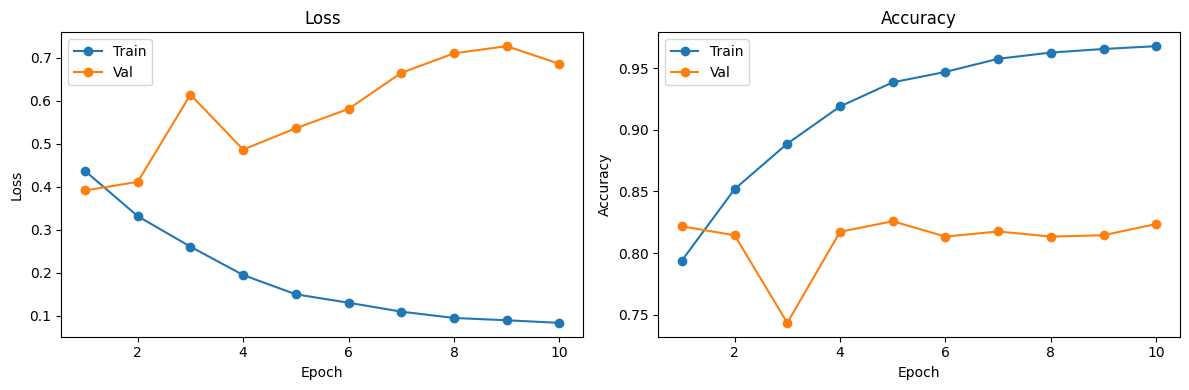

In [7]:
epochs = np.arange(1, EPOCHS + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
ax[0].plot(epochs, train_loss_hist, marker="o", label="Train")
ax[0].plot(epochs, val_loss_hist,   marker="o", label="Val")
ax[0].set_title("Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

# Accuracy curves
ax[1].plot(epochs, train_acc_hist, marker="o", label="Train")
ax[1].plot(epochs, val_acc_hist,   marker="o", label="Val")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()

plt.tight_layout()
plt.show()

### Evaluation and confusion matrix

  0%|          | 0/114 [00:00<?, ?it/s]


--- VISION MODEL (RESNET) VALIDATION RESULTS ---
Val Accuracy: 82.36%
Val F1 Score: 0.8250
Val ROC AUC:  0.9044


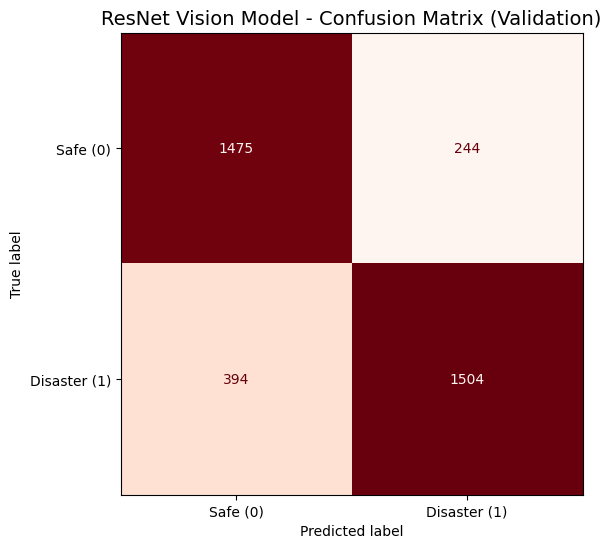

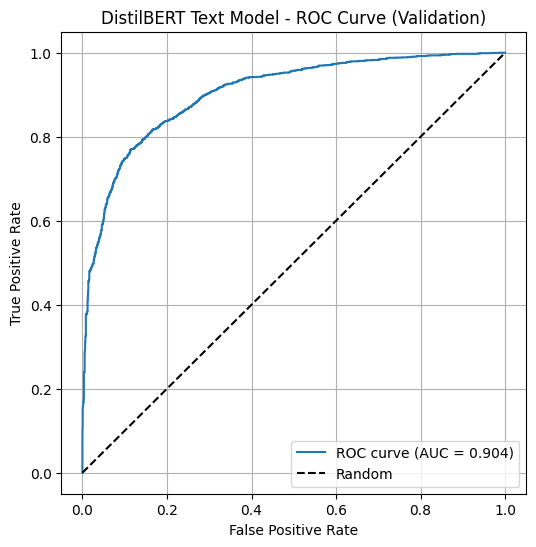

In [8]:
# Re-use evaluate to get predictions
val_loss, val_acc, val_preds, val_true, val_probs = evaluate(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=device,
)

val_f1  = f1_score(val_true, val_preds, average="binary")
val_auc = roc_auc_score(val_true, val_probs)


print("\n--- VISION MODEL (RESNET) VALIDATION RESULTS ---")
print(f"Val Accuracy: {val_acc * 100:.2f}%")
print(f"Val F1 Score: {val_f1:.4f}")
print(f"Val ROC AUC:  {val_auc:.4f}")

# Build confusion matrix
cm = confusion_matrix(val_true, val_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Safe (0)", "Disaster (1)"])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Reds", ax=ax, colorbar=False)
plt.title("ResNet Vision Model - Confusion Matrix (Validation)", fontsize=14)
plt.grid(False)
plt.show()

# Build ROC curve
fpr, tpr, thresholds = roc_curve(val_true, val_probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {val_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("DistilBERT Text Model - ROC Curve (Validation)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()